In [1]:
!pip install numpy pandas matplotlib

Normal rows (fault-free sessions): 29,594
Random seed: 42
------------------------------------------------------------
Key                  → TRAIN        → TEST
------------------------------------------------------------
F1_small             session_17      session_16
F1_medium            session_16      session_17
F1_severe            session_16      session_17
F2_small             session_16      session_17
F2_medium            session_17      session_16
F2_severe            session_17      session_16
F3_small             session_17      session_16
F3_medium            session_16      session_17
F3_severe            session_16      session_17
F4_small             session_16      session_17
F4_medium            session_16      session_17
F4_severe            session_17      session_16
combo_A              session_16      session_17
combo_B              session_16      session_17
fp_standalone        session_17      session_16
---------------------------------------------------------

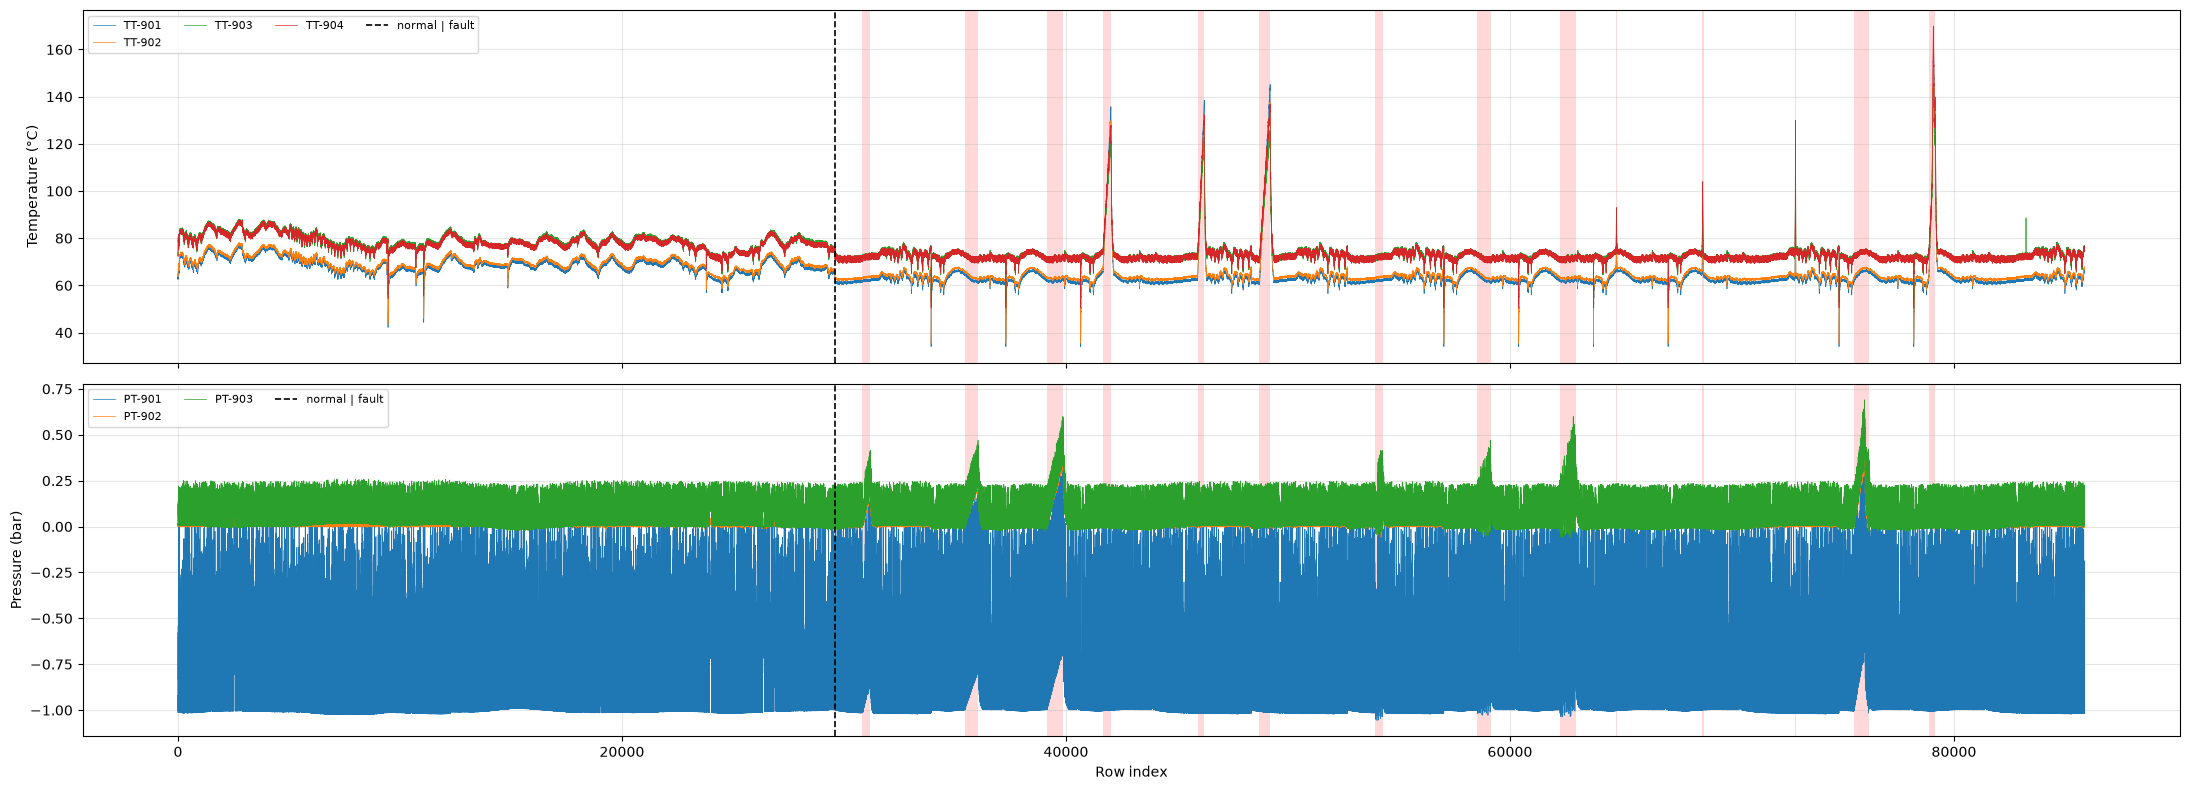

Key                    Session   File
--------------------------------------------------------------------------------
F1_small                    16   session_16_F1_small.csv
F1_medium                   17   session_17_F1_medium.csv
F1_severe                   17   session_17_F1_severe.csv
F2_small                    17   session_17_F2_small.csv
F2_medium                   16   session_16_F2_medium.csv
F2_severe                   16   session_16_F2_severe.csv
F3_small                    16   session_16_F3_small.csv
F3_medium                   17   session_17_F3_medium.csv
F3_severe                   17   session_17_F3_severe.csv
F4_small                    17   session_17_F4_small.csv
F4_medium                   17   session_17_F4_medium.csv
F4_severe                   16   session_16_F4_severe.csv
combo_A                     17   session_17_combo_A_F1severe_F3small.csv
combo_B                     17   session_17_combo_B_F2medium_F4severe.csv
fp_standalone               16   session_1

In [2]:
""" ============================================================
    TRAINING SET COMPILATION
    Combines fault-free sessions with a selected subset of the
    fault-injected files into a single train/test-ready dataset.
    ============================================================ """

import os
import glob
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

FEATURES = [
    'TT-901', 'TT-902', 'TT-903', 'TT-904', 'PT-901', 'PT-902', 'PT-903',
    'VSD-901_CORRENT', 'VSD-901_POWER', 'VSD-901_RPM', 'VSD-901_SPEED',
    'FT-201', 'FT-801', 'FT-901',
]

OUT_COLS = ['timestamp'] + FEATURES + ['is_injected_anomaly', 'anomaly_level', 'anomaly_type', 'severity_score', 'pt903_frozen_flag', 'source']

CLEAN_DIR = '../data/processed/clean'
AUG_DIR   = '../data/augmented'
OUT_DIR   = '../data/compiled'

os.makedirs(OUT_DIR, exist_ok=True)

# ---------------------------------------------------------------------------
# Load fault-free sessions (all except 16, 17) as normal data
# ---------------------------------------------------------------------------
all_files = sorted(glob.glob(os.path.join(CLEAN_DIR, '*.csv')))
frames = []

for path in all_files:
    session_n = int(os.path.basename(path).split('_')[2])
    if session_n in (16, 17):
        continue
    try:
        df = pd.read_csv(path, parse_dates=['timestamp'])
        if df.empty:
            print(f'Skipping empty: {os.path.basename(path)}')
            continue
        df['is_injected_anomaly'] = 0
        df['anomaly_level']       = 0
        df['anomaly_type']        = 'normal'
        df['severity_score']      = 0.0
        df['source']              = os.path.basename(path)
        frames.append(df[OUT_COLS])
    except pd.errors.EmptyDataError:
        print(f'Skipping bad file: {os.path.basename(path)}')

normal_df = pd.concat(frames, ignore_index=True).sort_values('timestamp').reset_index(drop=True)
print(f'Normal rows (fault-free sessions): {len(normal_df):,}')

# ---------------------------------------------------------------------------
# Fault scenario definitions.
# Each entry: (key, session_16_path, session_17_path)
# For each pair, one session is randomly assigned to TRAIN, the other to TEST.
# fp_on_fault is not included, since that scenario was dropped from the design.
# ---------------------------------------------------------------------------
FAULT_PAIRS = [
    ('F1_small',  os.path.join(AUG_DIR, 'single_faults/session_16_F1_small.csv'),  os.path.join(AUG_DIR, 'single_faults/session_17_F1_small.csv')),
    ('F1_medium', os.path.join(AUG_DIR, 'single_faults/session_16_F1_medium.csv'), os.path.join(AUG_DIR, 'single_faults/session_17_F1_medium.csv')),
    ('F1_severe', os.path.join(AUG_DIR, 'single_faults/session_16_F1_severe.csv'), os.path.join(AUG_DIR, 'single_faults/session_17_F1_severe.csv')),
    ('F2_small',  os.path.join(AUG_DIR, 'single_faults/session_16_F2_small.csv'),  os.path.join(AUG_DIR, 'single_faults/session_17_F2_small.csv')),
    ('F2_medium', os.path.join(AUG_DIR, 'single_faults/session_16_F2_medium.csv'), os.path.join(AUG_DIR, 'single_faults/session_17_F2_medium.csv')),
    ('F2_severe', os.path.join(AUG_DIR, 'single_faults/session_16_F2_severe.csv'), os.path.join(AUG_DIR, 'single_faults/session_17_F2_severe.csv')),
    ('F3_small',  os.path.join(AUG_DIR, 'single_faults/session_16_F3_small.csv'),  os.path.join(AUG_DIR, 'single_faults/session_17_F3_small.csv')),
    ('F3_medium', os.path.join(AUG_DIR, 'single_faults/session_16_F3_medium.csv'), os.path.join(AUG_DIR, 'single_faults/session_17_F3_medium.csv')),
    ('F3_severe', os.path.join(AUG_DIR, 'single_faults/session_16_F3_severe.csv'), os.path.join(AUG_DIR, 'single_faults/session_17_F3_severe.csv')),
    ('F4_small',  os.path.join(AUG_DIR, 'single_faults/session_16_F4_small.csv'),  os.path.join(AUG_DIR, 'single_faults/session_17_F4_small.csv')),
    ('F4_medium', os.path.join(AUG_DIR, 'single_faults/session_16_F4_medium.csv'), os.path.join(AUG_DIR, 'single_faults/session_17_F4_medium.csv')),
    ('F4_severe', os.path.join(AUG_DIR, 'single_faults/session_16_F4_severe.csv'), os.path.join(AUG_DIR, 'single_faults/session_17_F4_severe.csv')),
    ('combo_A', os.path.join(AUG_DIR, 'combined_faults/session_16_combo_A_F1severe_F3small.csv'),
                os.path.join(AUG_DIR, 'combined_faults/session_17_combo_A_F1severe_F3small.csv')),
    ('combo_B', os.path.join(AUG_DIR, 'combined_faults/session_16_combo_B_F2medium_F4severe.csv'),
                os.path.join(AUG_DIR, 'combined_faults/session_17_combo_B_F2medium_F4severe.csv')),
    ('fp_standalone', os.path.join(AUG_DIR, 'false_positives/session_16_fp_standalone_TT902.csv'),
                       os.path.join(AUG_DIR, 'false_positives/session_17_fp_standalone_TT903.csv')),
]

train_fault_files = []
test_fault_files  = []

print(f'Random seed: {RANDOM_SEED}')
print('-' * 60)
print(f'{"Key":<20} {"→ TRAIN":<15}{"→ TEST"}')
print('-' * 60)

for key, path_16, path_17 in FAULT_PAIRS:
    if random.random() < 0.5:
        train_path, test_path = path_16, path_17
        train_session, test_session = 16, 17
    else:
        train_path, test_path = path_17, path_16
        train_session, test_session = 17, 16

    train_fault_files.append((key, train_path, train_session))
    test_fault_files.append((key, test_path, test_session))

    print(f'{key:<20} session_{train_session:<7} session_{test_session}')

print('-' * 60)
print(f'Fault files → TRAIN: {len(train_fault_files)}  |  TEST: {len(test_fault_files)}')

# ---------------------------------------------------------------------------
# Build the final training CSV.
# severity_score is taken directly from each fault file, since it is already
# computed row by row during fault injection (including the max-of-two rule
# for combined faults, and 0.0 for false positives).
# ---------------------------------------------------------------------------
fault_frames = []
for key, path, session_num in train_fault_files:
    df = pd.read_csv(path, parse_dates=['timestamp'])
    df['source'] = os.path.basename(path)
    fault_frames.append(df[OUT_COLS])

fault_df_train = pd.concat(fault_frames, ignore_index=True)

# Remove the frozen PT-903 episode from the training portion. It occurs in
# Session 17, so it can appear in any training fault file that came from that
# session; removing these rows here keeps the real false-positive case out of
# training entirely, so it stays a genuinely unseen test case.
frozen_in_train = fault_df_train["pt903_frozen_flag"] == 1
n_frozen_removed = int(frozen_in_train.sum())
n_files_affected = fault_df_train.loc[frozen_in_train, "source"].nunique()
print(f"Removing {n_frozen_removed} frozen PT-903 episode rows from training, "
      f"found across {n_files_affected} training fault file(s)")
fault_df_train = fault_df_train[~frozen_in_train].reset_index(drop=True)

final_train_df = pd.concat([normal_df, fault_df_train], ignore_index=True)

n_normal = len(normal_df)
n_fault  = len(fault_df_train)
n_pos    = int(final_train_df['is_injected_anomaly'].sum())
n_neg    = len(final_train_df) - n_pos

print(f'Normal rows  : {n_normal:,}')
print(f'Fault rows   : {n_fault:,}')
print(f'Total rows   : {len(final_train_df):,}')
print(f'  label=0    : {n_neg:,}')
print(f'  label=1    : {n_pos:,}')
print()
print('severity_score breakdown:')
print(final_train_df['severity_score'].value_counts().sort_index().to_string())
print()
print('anomaly_type breakdown:')
print(final_train_df['anomaly_type'].value_counts().to_string())

out_path = os.path.join(OUT_DIR, f'train_compiled_severity_seed{RANDOM_SEED}.csv')
final_train_df.to_csv(out_path, index=False)
print(f'\nSaved → {out_path}')
print(f'Columns: {list(final_train_df.columns)}')

# ---------------------------------------------------------------------------
# Plot the entire training dataset grouped by sensor type
# ---------------------------------------------------------------------------
SENSOR_GROUPS = {
    'Temperature (°C)': ['TT-901', 'TT-902', 'TT-903', 'TT-904'],
    'Pressure (bar)':   ['PT-901', 'PT-902', 'PT-903'],
}

idx     = final_train_df.index.values
anomaly = final_train_df['is_injected_anomaly'].values

spans, in_span = [], False
for i, v in enumerate(anomaly):
    if v and not in_span:
        start, in_span = i, True
    elif not v and in_span:
        spans.append((start, i))
        in_span = False
if in_span:
    spans.append((start, len(anomaly)))

fig, axes = plt.subplots(len(SENSOR_GROUPS), 1, figsize=(22, 4 * len(SENSOR_GROUPS)), sharex=True)

for ax, (group_name, sensors) in zip(axes, SENSOR_GROUPS.items()):
    for sensor in sensors:
        ax.plot(idx, final_train_df[sensor].values, linewidth=0.5, label=sensor)
    for s, e in spans:
        ax.axvspan(s, e, color='red', alpha=0.15, linewidth=0)
    ax.axvline(n_normal, color='black', linestyle='--', linewidth=1.2, label='normal | fault')
    ax.set_ylabel(group_name, fontsize=10)
    ax.legend(fontsize=8, loc='upper left', ncol=len(sensors))
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Row index', fontsize=10)
plt.tight_layout()
plt.savefig("training_set_full.png", dpi=200, bbox_inches="tight")
plt.show()

# ---------------------------------------------------------------------------
# Test set summary
# ---------------------------------------------------------------------------
print(f'{"Key":<20} {"Session":>9}   File')
print('-' * 80)
for key, path, session_num in test_fault_files:
    print(f'{key:<20} {session_num:>9}   {os.path.basename(path)}')

print(f'\nTotal test fault files: {len(test_fault_files)}')

print('\nTEST_FILES (paste into pipeline):')
print('TEST_FILES = [')
for key, path, session_num in test_fault_files:
    print(f"    ('{session_num}_{key}', '{path}'),")
print(']')

In [3]:
""" ============================================================
    TEST SET COMPILATION
    Combines the fault files assigned to test into a single file,
    mirroring the structure of the compiled training set.
    ============================================================ """

test_frames = []
for key, path, session_num in test_fault_files:
    df = pd.read_csv(path, parse_dates=['timestamp'])
    df['source'] = os.path.basename(path)
    test_frames.append(df[OUT_COLS])

final_test_df = pd.concat(test_frames, ignore_index=True)

n_pos_test = int(final_test_df['is_injected_anomaly'].sum())
n_neg_test = len(final_test_df) - n_pos_test

print(f'Test rows total : {len(final_test_df):,}')
print(f'  label=0       : {n_neg_test:,}')
print(f'  label=1       : {n_pos_test:,}')
print()
print('severity_score breakdown (test):')
print(final_test_df['severity_score'].value_counts().sort_index().to_string())
print()
print('anomaly_type breakdown (test):')
print(final_test_df['anomaly_type'].value_counts().to_string())

test_out_path = os.path.join(OUT_DIR, f'test_compiled_severity_seed{RANDOM_SEED}.csv')
final_test_df.to_csv(test_out_path, index=False)
print(f'\nSaved → {test_out_path}')

Test rows total : 59,937
  label=0       : 54,134
  label=1       : 5,803

severity_score breakdown (test):
severity_score
0.00    54134
0.33     1468
0.67     1704
1.00     2631

anomaly_type breakdown (test):
anomaly_type
normal                         54122
clogged_filters                 2121
valve_fault                     2001
cooling_fault                   1260
bearing_fault                    202
cooling_fault+bearing_fault      180
clogged_filters+valve_fault       39
false_positive                    12

Saved → ../data/compiled/test_compiled_severity_seed42.csv
